In [1]:
import tensorflow as tf
import numpy as np
from tqdm import tqdm
import time
import os
import os
import tensorflow as tf
from tensorflow.keras import mixed_precision
import gc

tf.keras.mixed_precision.set_global_policy('float32')

# Note: Your model will now output float16. 
# Ensure your last layer is float32 for stability:
# self.out = tf.keras.layers.Dense(num_classes, dtype='float32')

# Standard Conda path for libdevice
conda_cuda_path = os.path.join(os.environ.get('CONDA_PREFIX', ''), "Library", "bin")
if os.path.exists(conda_cuda_path):
    os.environ['XLA_FLAGS'] = f"--xla_gpu_cuda_data_dir={conda_cuda_path}"
    print(f"XLA Path set to: {conda_cuda_path}")

# EMERGENCY BYPASS: If it still fails, disable JIT for now. 
# It will be slightly slower, but it will NOT crash.
USE_JIT = False

import os
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir="C:/Users/caspe/anaconda3/envs/SPIKEDETEC/Library/bin"'

XLA Path set to: C:\Users\caspe\anaconda3\envs\SPIKEDETEC\Library\bin


In [2]:
# 1. Load MNIST
(x_all, y_all), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. Flatten and Normalize (Standard step)
x_all = x_all.reshape(-1, 784).astype('uint8') / 255.0
x_test = x_test.reshape(-1, 784).astype('uint8') / 255.0

# 3. Create FIXED Permutation (The "p" in pMNIST)
rng = np.random.RandomState(42)
perm = rng.permutation(784)

x_all = x_all[:, perm]
x_test = x_test[:, perm]

# --- NEW: Train/Val Split (90% Train, 10% Val) ---
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(
    x_all, y_all, test_size=0.1, random_state=42, stratify=y_all
)

# 4. Reshape to [Batch, Time, Channels] for your RNN
x_train = x_train[:, :, np.newaxis]
x_val   = x_val[:, :, np.newaxis]
x_test  = x_test[:, :, np.newaxis]

# 5. Labels to int32
y_train = y_train.astype('int32')
y_val   = y_val.astype('int32')
y_test  = y_test.astype('int32')

# 6. Build datasets
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(10000).batch(256)
val_ds   = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(256)
test_ds  = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(256)

print(f"pMNIST Ready. Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

pMNIST Ready. Train: (54000, 784, 1), Val: (6000, 784, 1), Test: (10000, 784, 1)


## Clean environment and drift calc


In [3]:
import tensorflow as tf
# Forcefully disable the strict determinism flag at the TF level
try:
    tf.config.experimental.enable_op_determinism(False)
    print("Success: Strict determinism disabled.")
except:
    print("Warning: Could not toggle flag. If Phase 1 fails, restart kernel.")
def reset_seeds():
    import os
    import gc
    import random
    import numpy as np

    # 1. Clear session
    tf.keras.backend.clear_session()
    
    # 2. Disable strict determinism to allow GPU kernels to run
    os.environ['TF_DETERMINISTIC_OPS'] = '0' 
    
    # 3. Hard-lock all seeds
    os.environ['PYTHONHASHSEED'] = str(42)
    random.seed(42)
    np.random.seed(42)
    tf.random.set_seed(42)
    tf.keras.utils.set_random_seed(42) 
    
    gc.collect()
    print("Environment Reset: Seeds locked at 42. Strict determinism disabled.")

##  Oscillatory global field block 

In [4]:
import tensorflow as tf
import numpy as np
from tqdm import tqdm
import scipy.linalg
import math
import os, gc, random
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
DATA_PERCENT =1
BATCH_SIZE = 6*64
EPOCHS = 3
HIDDEN = 16 
BASE_STRENGTH = -0.075 
PERIOD = 128.0 
LAMBDA_SLOW = 0.09 
JITTER_SCALE = 2.5 
REST_BASELINE = 1

# --- 2. THE JITTERED CELL ---
class JitteredFeedbackCell(tf.keras.layers.Layer):
    def __init__(self, units=16, strength=0.0, period=256.0, lambda_slow=0.05, mode="active", **kwargs):
        super().__init__(**kwargs)
        self.units = units
        # State: [Hidden, Global_EMA, Phase]
        self.state_size = [units, units, 1] 
        self.strength = strength 
        self.period = period
        self.lambda_slow = lambda_slow
        self.mode = mode
        self.jitter_scale = JITTER_SCALE

    def build(self, input_shape):
        self.w_in = self.add_weight(shape=(input_shape[-1], self.units), name="w_in", initializer="glorot_uniform")
        self.w_rec = self.add_weight(shape=(self.units, self.units), name="w_rec",
                                     initializer=tf.keras.initializers.Orthogonal(gain=1.0))
        self.bias = self.add_weight(shape=(self.units,), name="bias", initializer="zeros")

    def call(self, inputs, states):
        prev_h, prev_G, prev_phase = states
        
        # 1. Feedback Signal Generation
        half = self.units // 2
        raw_signal = tf.concat([prev_h[:, half:], prev_h[:, :half]], axis=1)
        source_signal = tf.stop_gradient(raw_signal) if self.mode == "probe" else raw_signal

        # 2. Global State EMA & Phase
        new_G = (1.0 - self.lambda_slow) * prev_G + self.lambda_slow * source_signal
        G_norm = (new_G - tf.reduce_mean(new_G, axis=-1, keepdims=True)) / (tf.math.reduce_std(new_G, axis=-1, keepdims=True) + 1e-6)
        new_phase = prev_phase + (2.0 * math.pi / self.period)

        # 3. BALANCED ADDITIVE JITTER
        oscillator = tf.math.sin(new_phase)
        
        if self.mode == "active":
            # We calculate the mean but subtract a 'resting' offset (e.g., 0.1)
            # Or better: center the mean against its own recent history
            # For now, let's use a simple zero-centering shift:
            bias_signal = tf.reduce_mean(source_signal, axis=-1, keepdims=True) - 0.1
            combined_signal = oscillator + (JITTER_SCALE * bias_signal)
        else:
            combined_signal = oscillator

        # 4. Field Effect 
        current_strength = self.strength * combined_signal if self.mode != "passive" else 0.0
        field_effect = REST_BASELINE + (current_strength * tf.tanh(G_norm))
        
        # 5. Core RNN Computation with ELU for better +/- Balance
        z = (tf.matmul(inputs, self.w_in) + tf.matmul(prev_h, self.w_rec) + self.bias) * field_effect
        
        # SWAP: Using ELU instead of LeakyReLU to allow deeper negative states
        h = (0.3 * prev_h) + (0.7 * tf.nn.elu(z))
        
        return h, [h, new_G, new_phase]
    
class OscillatingResonator(tf.keras.Model):
    def __init__(self, hidden=16, num_classes=10, strength=0.0, mode="active"):
        super().__init__()
        self.rnn1 = tf.keras.layers.RNN(JitteredFeedbackCell(hidden, strength, PERIOD, LAMBDA_SLOW, mode=mode), return_sequences=True)
        self.rnn2 = tf.keras.layers.RNN(JitteredFeedbackCell(hidden, strength, PERIOD, LAMBDA_SLOW, mode=mode), return_sequences=True)
        self.rnn3 = tf.keras.layers.RNN(JitteredFeedbackCell(hidden, strength, PERIOD, LAMBDA_SLOW, mode=mode), return_sequences=True)
        self.out = tf.keras.layers.Dense(num_classes, dtype='float32')

    def call(self, x, training=False):
        h1 = self.rnn1(x, training=training)
        h2 = self.rnn2(h1, training=training)
        h3 = self.rnn3(h2, training=training)
        return self.out(h3[:, -1, :]), h3

# --- 3. UTILITIES ---
def print_history_summary(history, model, model_name="Model", test_acc=None, data_percent=DATA_PERCENT):
    cell = model.rnn1.cell
    total_params = model.count_params()
    
    print(f"\n{'='*145}")
    print(f" DATA LOG: {model_name}")
    # Updated CONFIG line to use cell.jitter_scale and cell.period
    print(f" CONFIG: Hidden: {cell.units} | Params: {total_params:,} | F-Wgt: {cell.strength:.4f} | "
          f"L-Slow (τ): {cell.lambda_slow:.3f} | Jitter: {cell.jitter_scale:.2f} | Period: {cell.period:.1f} | Data: {data_percent*100:.2f}%")
    print(f"{'='*145}")
    
    header = f"{'Epoch':<6} | {'Loss':<7} | {'Val-Acc%':<8} | {'Rank':<6} | {'Sync':<6} | {'Entrp':<6} | {'A-Corr':<7} | {'Intf':<6} | {'F-Wgt':<6}"
    print(header)
    print(f"{'-'*145}")

    for i in range(len(history['loss'])):
        m = history['hidden_metrics'][i]
        current_f_wgt = cell.strength 

        print(f"{i+1:<6} | {history['loss'][i]:<7.3f} | {history['acc'][i]*100:<8.2f} | "
              f"{m.get('effective_rank', 0):<6.2f} | {m.get('synchrony', 0):<6.3f} | {m.get('entropy', 0):<6.2f} | "
              f"{m.get('a_corr', 0):<7.3f} | {m.get('interference', 0):<6.3f} | {current_f_wgt:<6.3f}")
    
    final_val_acc = history['acc'][-1] * 100
    test_str = f"{test_acc*100:.2f}%" if test_acc is not None else "N/A"
    
    print(f"{'-'*140}")
    print(f" FINAL PERFORMANCE: Validation Acc: {final_val_acc:.2f}% | TEST ACCURACY: {test_str}")
    print(f" FINAL DYNAMICS   : Rank: {m.get('effective_rank',0):.2f} | Entropy: {m.get('entropy',0):.2f} | Synchrony: {m.get('synchrony',0):.3f}")
    print(f"{'='*140}\n")

# --- 4. DRIFT CALC ---
def get_model_kernels(model):
    """Safely extracts Recurrent weights (w_rec) from all layers."""
    kernels = []
    # Grab w_rec from the 3 RNN layers
    for layer in [model.rnn1, model.rnn2, model.rnn3]:
        if hasattr(layer.cell, 'w_rec'):
            kernels.append(layer.cell.w_rec.numpy().copy())
    return kernels

def calculate_drift(initial_kernels, current_model):
    """Calculates L2 Norm distance between initial and current weights."""
    current_kernels = get_model_kernels(current_model)
    if not initial_kernels: return 0.0
    
    # Sum of Euclidean distances for all layers
    total_drift = sum([np.linalg.norm(c - i) for c, i in zip(current_kernels, initial_kernels)])
    return total_drift

def get_full_kernel_list(model):
    """Extracts all 7 trainable kernels: (In/Rec x 3 layers) + Dense Out."""
    k = []
    for layer in [model.rnn1, model.rnn2, model.rnn3]:
        k.append(layer.cell.w_in.numpy().copy())
        k.append(layer.cell.w_rec.numpy().copy())
    k.append(model.out.kernel.numpy().copy())
    return k

def calculate_final_drift_vector(initial_kernels, current_model):
    """Returns a list of 7 L2 norms representing drift per weight matrix."""
    current_kernels = get_full_kernel_list(current_model)
    return [np.linalg.norm(c - i) for c, i in zip(current_kernels, initial_kernels)]

# --- 4. TRAINING PHASE ---
def train_phase(model, train_data, val_data, epochs=3):
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.002)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    history = {"loss": [], "acc": [], "hidden_metrics": []}

    # --- FIX 1: Turn off JIT compile to avoid libdevice error ---
    @tf.function(jit_compile=False) 
    def train_step(x, y):
        with tf.GradientTape() as tape:
            logits, _ = model(x, training=True)
            loss_v = loss_fn(y, logits)
        grads = tape.gradient(loss_v, model.trainable_variables)
        optimizer.apply_gradients(zip(grads, model.trainable_variables))
        return loss_v, logits

    for epoch in range(epochs):
        acc_metric = tf.keras.metrics.SparseCategoricalAccuracy()
        pbar = tqdm(train_data, desc=f"Epoch {epoch+1}")
        
        for x_b, y_b in pbar:
            loss_v, logits = train_step(x_b, y_b)
            acc_metric.update_state(y_b, logits)
            
            if random.random() < 0.1: 
                pbar.set_postfix({"loss": f"{float(loss_v):.4f}", "acc": f"{acc_metric.result():.2%}"})

        # Validation
        for x_v, y_v in val_data.take(1):
            logits_v, h_seq_v = model(x_v, training=False)
            val_acc = np.mean(np.argmax(logits_v.numpy(), axis=-1) == y_v.numpy())
            h_final = h_seq_v.numpy()[:, -1, :]
            
            s = scipy.linalg.svdvals(h_final)
            p = s / (np.sum(s) + 1e-10)
            
            history["loss"].append(float(loss_v))
            history["acc"].append(val_acc)
            history["hidden_metrics"].append({
                "effective_rank": np.exp(-np.sum(p * np.log(p + 1e-10))),
                "synchrony": (np.sum(np.abs(np.corrcoef(h_final.T))) - HIDDEN) / (HIDDEN**2 - HIDDEN),
                "entropy": -np.sum((np.histogram(h_final, bins=50)[0]/len(h_final)+1e-10) * np.log2(np.histogram(h_final, bins=50)[0]/len(h_final)+1e-10)),
                "a_corr": np.mean(np.abs(np.corrcoef(h_seq_v.numpy()[0].T))), 
                "interference": np.std(np.mean(h_seq_v.numpy(), axis=1))
            })
            
    return history

# --- 5. EXECUTION ---
def reset_env():
    tf.keras.backend.clear_session()
    random.seed(42); np.random.seed(42); tf.random.set_seed(42)
    gc.collect()

# SETUP DATA
num_train = int(len(x_train) * DATA_PERCENT)
num_val = int(len(x_val)*DATA_PERCENT)
num_test  = int(len(x_test) * DATA_PERCENT)

train_ds = tf.data.Dataset.from_tensor_slices((x_train[:num_train], y_train[:num_train])) \
    .shuffle(5000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_val[:1000], y_val[:1000])) \
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds_subset = tf.data.Dataset.from_tensor_slices((x_test[:num_test], y_test[:num_test])) \
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Test Run Ready: Samples -> Train: {num_train}, Val: {num_val}, Data %: {DATA_PERCENT*100}")


# --- RUN 1: ACTIVE ---
reset_env()
print("\n[Phase 1] Training Active...")

model_active = OscillatingResonator(hidden=HIDDEN, strength=BASE_STRENGTH, mode="active")
_ = model_active(tf.zeros((1, 784, 1))) 
init_active = get_full_kernel_list(model_active)
hist_active = train_phase(model_active, train_ds, val_ds, epochs=EPOCHS)
test_acc_active = np.mean([np.mean(np.argmax(model_active(x, training=False)[0].numpy(), axis=-1) == y.numpy()) for x, y in test_ds_subset])
drift_active = calculate_final_drift_vector(init_active, model_active)
print_history_summary(hist_active, model_active, "ACTIVE (JITTERED)", test_acc=test_acc_active)
'''

# --- RUN 2: PROBE ---
reset_env()
print("\n[Phase 2] Training probe...")

model_probe = OscillatingResonator(hidden=HIDDEN, strength=BASE_STRENGTH, mode="probe")
_ = model_probe(tf.zeros((1, 784, 1)))
init_probe = get_full_kernel_list(model_probe)
hist_probe = train_phase(model_probe, train_ds, val_ds, epochs=EPOCHS)
test_acc_probe = np.mean([np.mean(np.argmax(model_probe(x, training=False)[0].numpy(), axis=-1) == y.numpy()) for x, y in test_ds_subset])
drift_probe = calculate_final_drift_vector(init_probe, model_probe)
print_history_summary(hist_probe, model_probe, "PROBE (GHOST SINE)", test_acc=test_acc_probe)


# --- RUN 3: PASSIVE ---
reset_env()
print("\n[Phase 3] Training baseline...")

model_passive = OscillatingResonator(hidden=HIDDEN, strength=BASE_STRENGTH, mode="passive")
_ = model_passive(tf.zeros((1, 784, 1)))
init_passive = get_full_kernel_list(model_passive)
hist_passive = train_phase(model_passive, train_ds, val_ds, epochs=EPOCHS)
test_acc_passive = np.mean([np.mean(np.argmax(model_passive(x, training=False)[0].numpy(), axis=-1) == y.numpy()) for x, y in test_ds_subset])
drift_passive = calculate_final_drift_vector(init_passive, model_passive)
print_history_summary(hist_passive, model_passive, "PASSIVE (BASELINE)", test_acc=test_acc_passive)

'''

Test Run Ready: Samples -> Train: 54000, Val: 6000, Data %: 100

[Phase 1] Training Active...


Epoch 3: 100%|██████████| 141/141 [06:47<00:00,  2.89s/it, loss=1.3066, acc=53.37%]



 DATA LOG: ACTIVE (JITTERED)
 CONFIG: Hidden: 16 | Params: 1,514 | F-Wgt: -0.0750 | L-Slow (τ): 0.090 | Jitter: 2.50 | Period: 128.0 | Data: 100.00%
Epoch  | Loss    | Val-Acc% | Rank   | Sync   | Entrp  | A-Corr  | Intf   | F-Wgt 
-------------------------------------------------------------------------------------------------------------------------------------------------
1      | 1.716   | 42.71    | 10.06  | 0.311  | 13.22  | 0.326   | 0.220  | -0.075
2      | 1.378   | 52.60    | 10.40  | 0.313  | 7.91   | 0.323   | 0.231  | -0.075
3      | 1.313   | 54.95    | 10.30  | 0.314  | 3.33   | 0.301   | 0.280  | -0.075
--------------------------------------------------------------------------------------------------------------------------------------------
 FINAL PERFORMANCE: Validation Acc: 54.95% | TEST ACCURACY: 53.78%
 FINAL DYNAMICS   : Rank: 10.30 | Entropy: 3.33 | Synchrony: 0.314



'\n\n# --- RUN 2: PROBE ---\nreset_env()\nprint("\n[Phase 2] Training probe...")\n\nmodel_probe = OscillatingResonator(hidden=HIDDEN, strength=BASE_STRENGTH, mode="probe")\n_ = model_probe(tf.zeros((1, 784, 1)))\ninit_probe = get_full_kernel_list(model_probe)\nhist_probe = train_phase(model_probe, train_ds, val_ds, epochs=EPOCHS)\ntest_acc_probe = np.mean([np.mean(np.argmax(model_probe(x, training=False)[0].numpy(), axis=-1) == y.numpy()) for x, y in test_ds_subset])\ndrift_probe = calculate_final_drift_vector(init_probe, model_probe)\nprint_history_summary(hist_probe, model_probe, "PROBE (GHOST SINE)", test_acc=test_acc_probe)\n\n\n# --- RUN 3: PASSIVE ---\nreset_env()\nprint("\n[Phase 3] Training baseline...")\n\nmodel_passive = OscillatingResonator(hidden=HIDDEN, strength=BASE_STRENGTH, mode="passive")\n_ = model_passive(tf.zeros((1, 784, 1)))\ninit_passive = get_full_kernel_list(model_passive)\nhist_passive = train_phase(model_passive, train_ds, val_ds, epochs=EPOCHS)\ntest_acc_pas

## Visualizing metrics


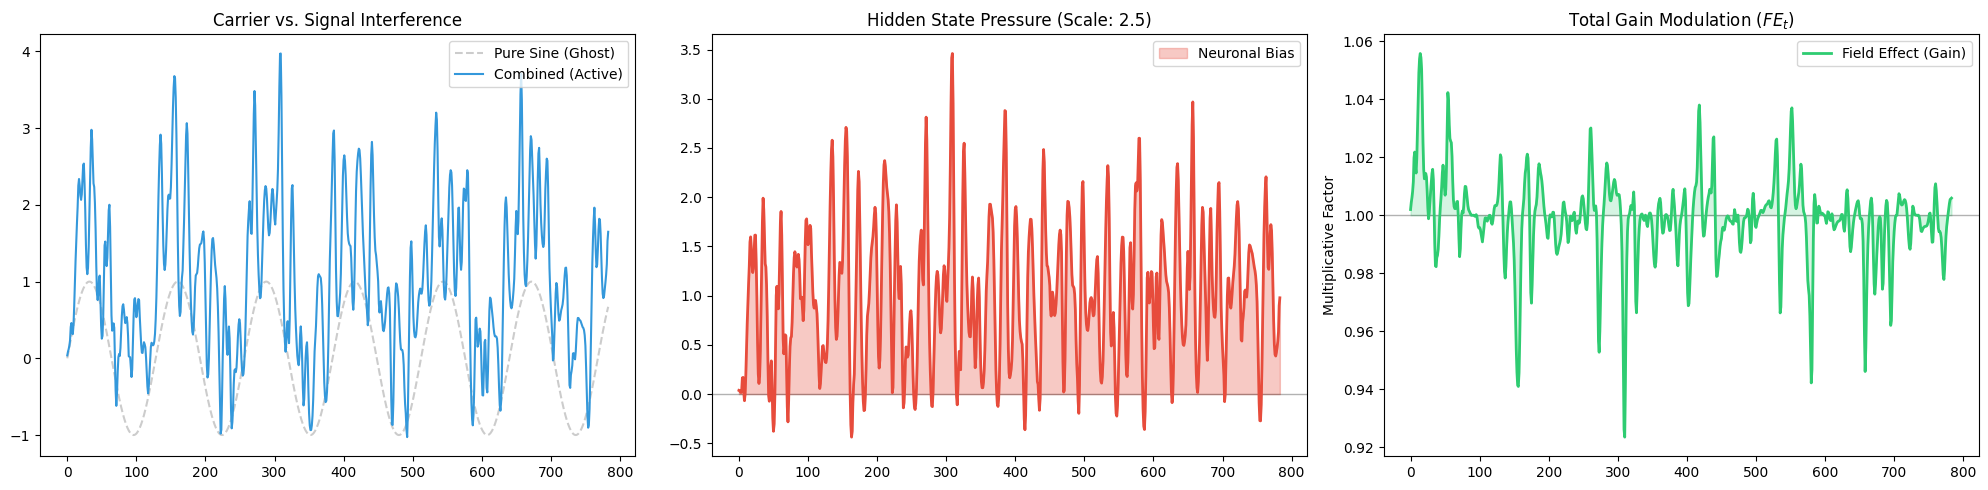

In [5]:
def plot_field_jitter(model, sample_batch):
    # 1. Extract hidden sequences
    logits, h_seq = model(sample_batch[:1], training=False)
    h_np = h_seq[0].numpy() # Shape: (784, HIDDEN)
    
    # 2. Reconstruct physics components
    base_delta = (2.0 * np.pi) / PERIOD
    steps = np.arange(h_np.shape[0])
    phase = steps * base_delta
    
    # Raw Oscillator and Neuronal Bias
    ghost_field = np.sin(phase)
    activity_bias = JITTER_SCALE * np.mean(h_np, axis=-1) 
    combined_signal = ghost_field + activity_bias
    
    # Reconstruct G_norm (Simplified EMA for visualization)
    # This approximates the 'new_G' EMA in your cell logic
    ema_g = 0
    g_history = []
    for step_h in h_np:
        # Shuffling the signal as per your 'half' concat logic
        half = len(step_h) // 2
        shuffled = np.concatenate([step_h[half:], step_h[:half]])
        ema_g = (1.0 - LAMBDA_SLOW) * ema_g + LAMBDA_SLOW * shuffled
        g_history.append(ema_g)
    
    g_history = np.array(g_history)
    # Z-score normalization for the tanh gating
    g_norm = (g_history - np.mean(g_history)) / (np.std(g_history) + 1e-6)
    
    # Calculate Final Gain Modulation (Field Effect)
    # FE = 1 + (strength * combined * tanh(G_norm))
    # We take the mean across neurons for the final visualization
    field_effect = 1.0 + (BASE_STRENGTH * combined_signal[:, None] * np.tanh(g_norm))
    field_effect_mean = np.mean(field_effect, axis=-1)

    # 3. Plotting
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # Plot 1: Interference Pattern
    axes[0].plot(ghost_field, label="Pure Sine (Ghost)", color='gray', alpha=0.4, linestyle='--')
    axes[0].plot(combined_signal, label="Combined (Active)", color='#3498db', linewidth=1.5)
    axes[0].set_title("Carrier vs. Signal Interference")
    axes[0].legend()

    # Plot 2: Neuronal Bias (The DC Offset)
    axes[1].axhline(0, color='black', lw=1, alpha=0.3)
    axes[1].fill_between(steps, activity_bias, color='#e74c3c', alpha=0.3, label="Neuronal Bias")
    axes[1].plot(activity_bias, color='#e74c3c', lw=2)
    axes[1].set_title(f"Hidden State Pressure (Scale: {JITTER_SCALE})")
    axes[1].legend()

    # Plot 3: Resulting Gain Modulation (The Field Effect)
    axes[2].axhline(1.0, color='black', lw=1, alpha=0.3) # 1.0 is neutral gain
    axes[2].plot(field_effect_mean, color='#2ecc71', lw=2, label="Field Effect (Gain)")
    axes[2].fill_between(steps, 1.0, field_effect_mean, color='#2ecc71', alpha=0.2)
    axes[2].set_title("Total Gain Modulation ($FE_t$)")
    axes[2].set_ylabel("Multiplicative Factor")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

# Run it!
test_batch, _ = next(iter(val_ds))
plot_field_jitter(model_active, test_batch)

In [6]:
def plot_full_gf_benchmarks(histories, names=['Passive', 'Ghost Sine', 'Active Sine']):
    # 1. Pre-process: Flatten 'hidden_metrics' into the main history dict
    processed_histories = []
    for h in histories:
        new_h = {k: v for k, v in h.items() if k != 'hidden_metrics'}
        if 'hidden_metrics' in h:
            metric_keys = h['hidden_metrics'][0].keys()
            for m_key in metric_keys:
                # Map keys for the plotter
                plot_key = 'rank' if m_key == 'effective_rank' else ('sync' if m_key == 'synchrony' else m_key)
                new_h[plot_key] = [epoch_metrics[m_key] for epoch_metrics in h['hidden_metrics']]
        processed_histories.append(new_h)

    epochs = range(1, len(processed_histories[0]['loss']) + 1)
    
    metrics = [
        ('loss', 'Loss', 'Value'),
        ('acc', 'Val-Acc%', 'Percentage'),
        ('rank', 'Effective Rank', 'Rank Value'),
        ('sync', 'Synchrony', 'Coefficient'),
        ('drift', 'Weight Drift', 'L2 Norm'),
        ('interference', 'Interference', 'Std Dev')
    ]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    # Colors: Grey (Passive), Blue (Probe), Red (Active)
    colors = ['#7f8c8d', '#3498db', '#e74c3c']

    for i, (key, title, ylabel) in enumerate(metrics):
        ax = axes[i]
        for h, name, color in zip(processed_histories, names, colors):
            if key in h and len(h[key]) > 0:
                data = h[key]
                # Scale accuracy to 100%
                if key == 'acc': data = [d * 100 for d in data]
                
                # Ensure data matches epoch length (handles drift if only 1 value)
                if len(data) == len(epochs):
                    ax.plot(epochs, data, label=name, marker='o', lw=2, color=color)
                else:
                    # If it's a single final value, plot as a horizontal dashed line
                    ax.axhline(y=data[-1], color=color, linestyle='--', alpha=0.5, label=f"{name} (Final)")
        
        ax.set_title(title, fontweight='bold')
        ax.set_ylabel(ylabel)
        ax.set_xlabel('Epoch')
        ax.grid(True, linestyle='--', alpha=0.6)
        if i == 0: ax.legend()

    plt.suptitle(f"Resonator Triple-Benchmark (Period: {PERIOD}, Strength: {BASE_STRENGTH})", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Call with all three histories
# Order matters: Passive first, then Probe, then Active to match the color list
plot_full_gf_benchmarks(
    [hist_passive, hist_probe, hist_active], 
    names=['Passive (Baseline)', 'Ghost Sine (Probe)', 'Active Sine (Jittered)']
)

NameError: name 'hist_passive' is not defined

## visualizing weights

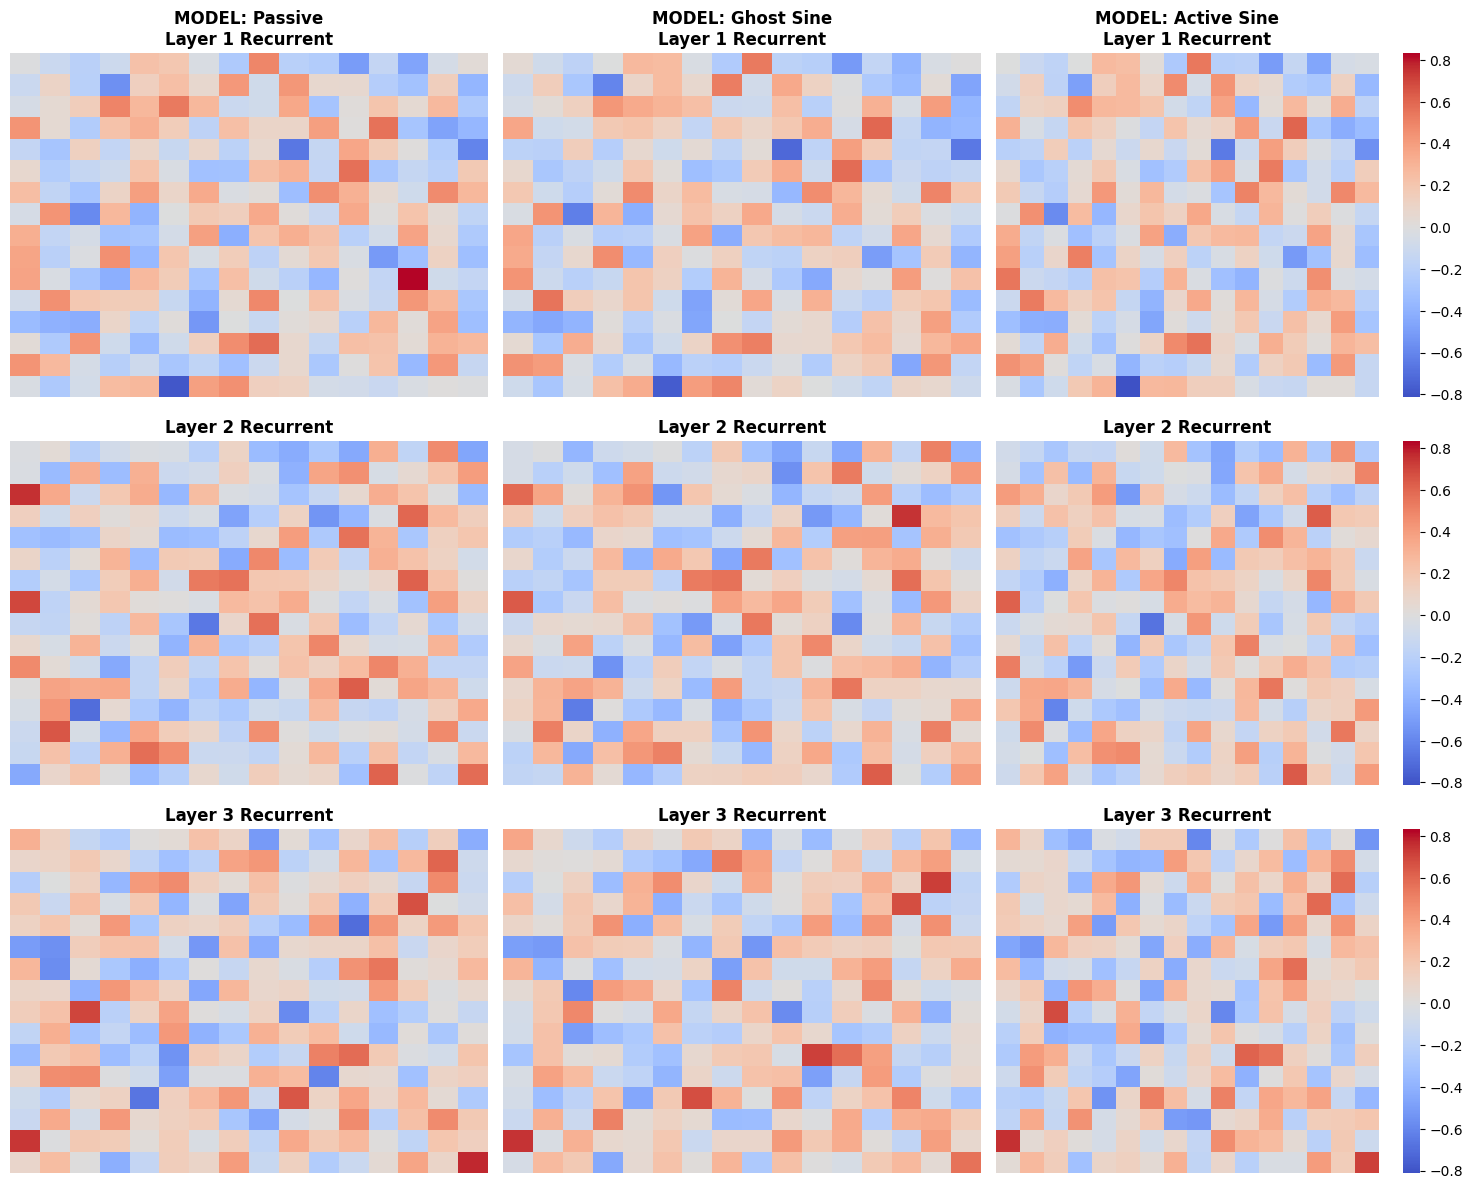

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_all_weights_comparison(models, model_names=['Passive', 'Ghost Sine', 'Active Sine']):
    num_models = len(models)
    num_layers = 3 
    
    fig, axes = plt.subplots(num_layers, num_models, figsize=(5 * num_models, 4 * num_layers))
    
    # Use a consistent color scale to make comparisons valid
    # Finding a global vmin/vmax for all models ensures the 'heat' is comparable
    all_weights = []
    for model in models:
        for layer in [model.rnn1, model.rnn2, model.rnn3]:
            all_weights.append(layer.cell.w_rec.numpy())
    v_min, v_max = np.min(all_weights), np.max(all_weights)

    for m_idx, (model, name) in enumerate(zip(models, model_names)):
        layers = [model.rnn1, model.rnn2, model.rnn3]
        
        for l_idx, rnn_layer in enumerate(layers):
            w_rec = rnn_layer.cell.w_rec.numpy()
            ax = axes[l_idx, m_idx]
            
            # center=0 ensures blue is negative, red is positive
            sns.heatmap(w_rec, cmap='coolwarm', center=0, 
                        vmin=v_min, vmax=v_max,
                        ax=ax, cbar=(m_idx == num_models - 1))
            
            title_prefix = f"MODEL: {name}\n" if l_idx == 0 else ""
            ax.set_title(f"{title_prefix}Layer {l_idx+1} Recurrent", fontweight='bold')
            ax.set_xticks([]); ax.set_yticks([]) # Clean up labels for scannability
                
    plt.tight_layout()
    plt.show()

# Run the comparison across the full spectrum
plot_all_weights_comparison(
    [model_passive, model_probe, model_active], 
    model_names=['Passive', 'Ghost Sine', 'Active Sine']
)

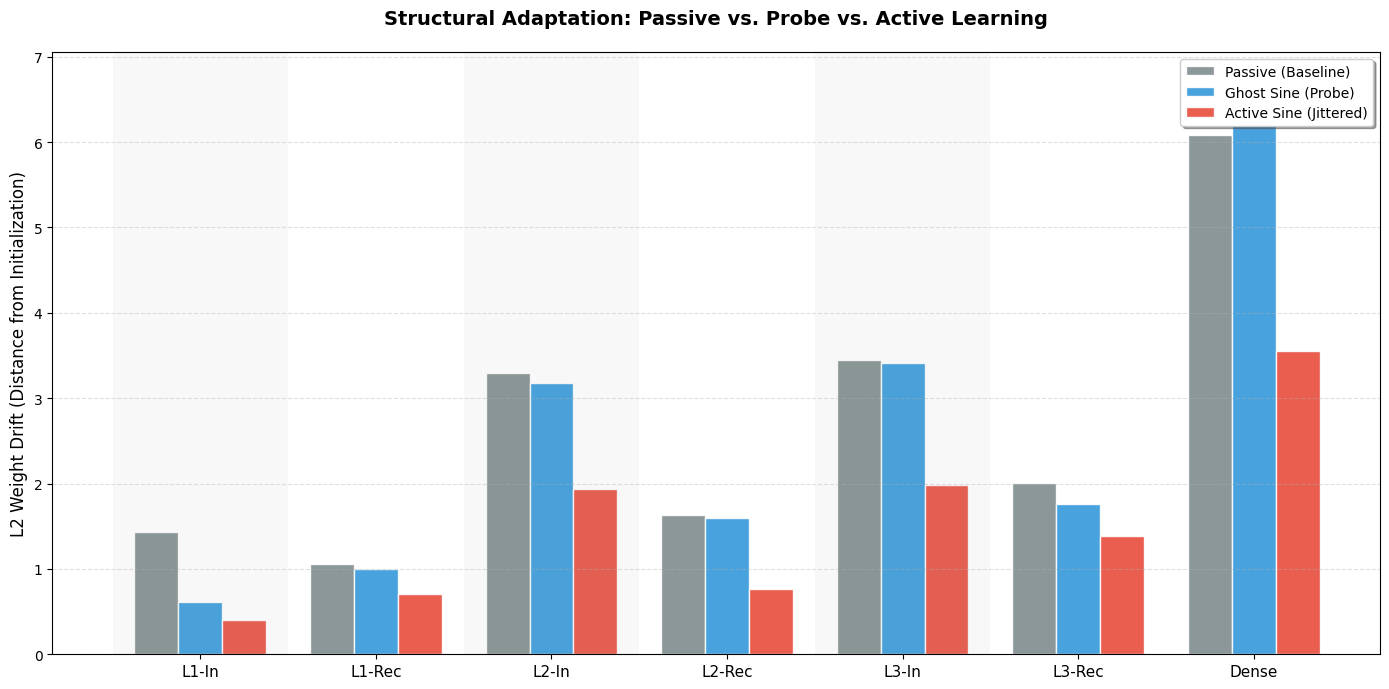

In [ ]:
def plot_drift_comparison(drifts_list, names=['Passive', 'Ghost Sine', 'Active Sine']):
    num_kernels = len(drifts_list[0])
    # Mapping the 7 kernel indices to readable names
    labels = ["L1-In", "L1-Rec", "L2-In", "L2-Rec", "L3-In", "L3-Rec", "Dense"]
    
    x = np.arange(len(labels))
    # Narrower width to fit 3 bars side-by-side
    width = 0.25 
    plt.figure(figsize=(14, 7))
    
    # Matching the color palette from our history and heatmap plots
    colors = ['#7f8c8d', '#3498db', '#e74c3c'] 
    
    for i, (drift, name) in enumerate(zip(drifts_list, names)):
        # Calculate offset so 3 bars sit side-by-side centered on the tick
        offset = (i - 1) * width 
        plt.bar(x + offset, drift, width, label=name, color=colors[i % len(colors)], alpha=0.9, edgecolor='white')

    plt.ylabel('L2 Weight Drift (Distance from Initialization)', fontsize=12)
    plt.title('Structural Adaptation: Passive vs. Probe vs. Active Learning', fontweight='bold', pad=20, fontsize=14)
    plt.xticks(x, labels, fontsize=11)
    plt.legend(frameon=True, shadow=True)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Adding a light background highlight for recurrent vs input layers
    for i in range(0, 6, 2):
        plt.axvspan(i-0.5, i+0.5, facecolor='grey', alpha=0.05)

    plt.tight_layout()
    plt.show()

# Final execution call with all three drift vectors
plot_drift_comparison(
    [drift_passive, drift_probe, drift_active], 
    names=['Passive (Baseline)', 'Ghost Sine (Probe)', 'Active Sine (Jittered)']
)

## Salience map

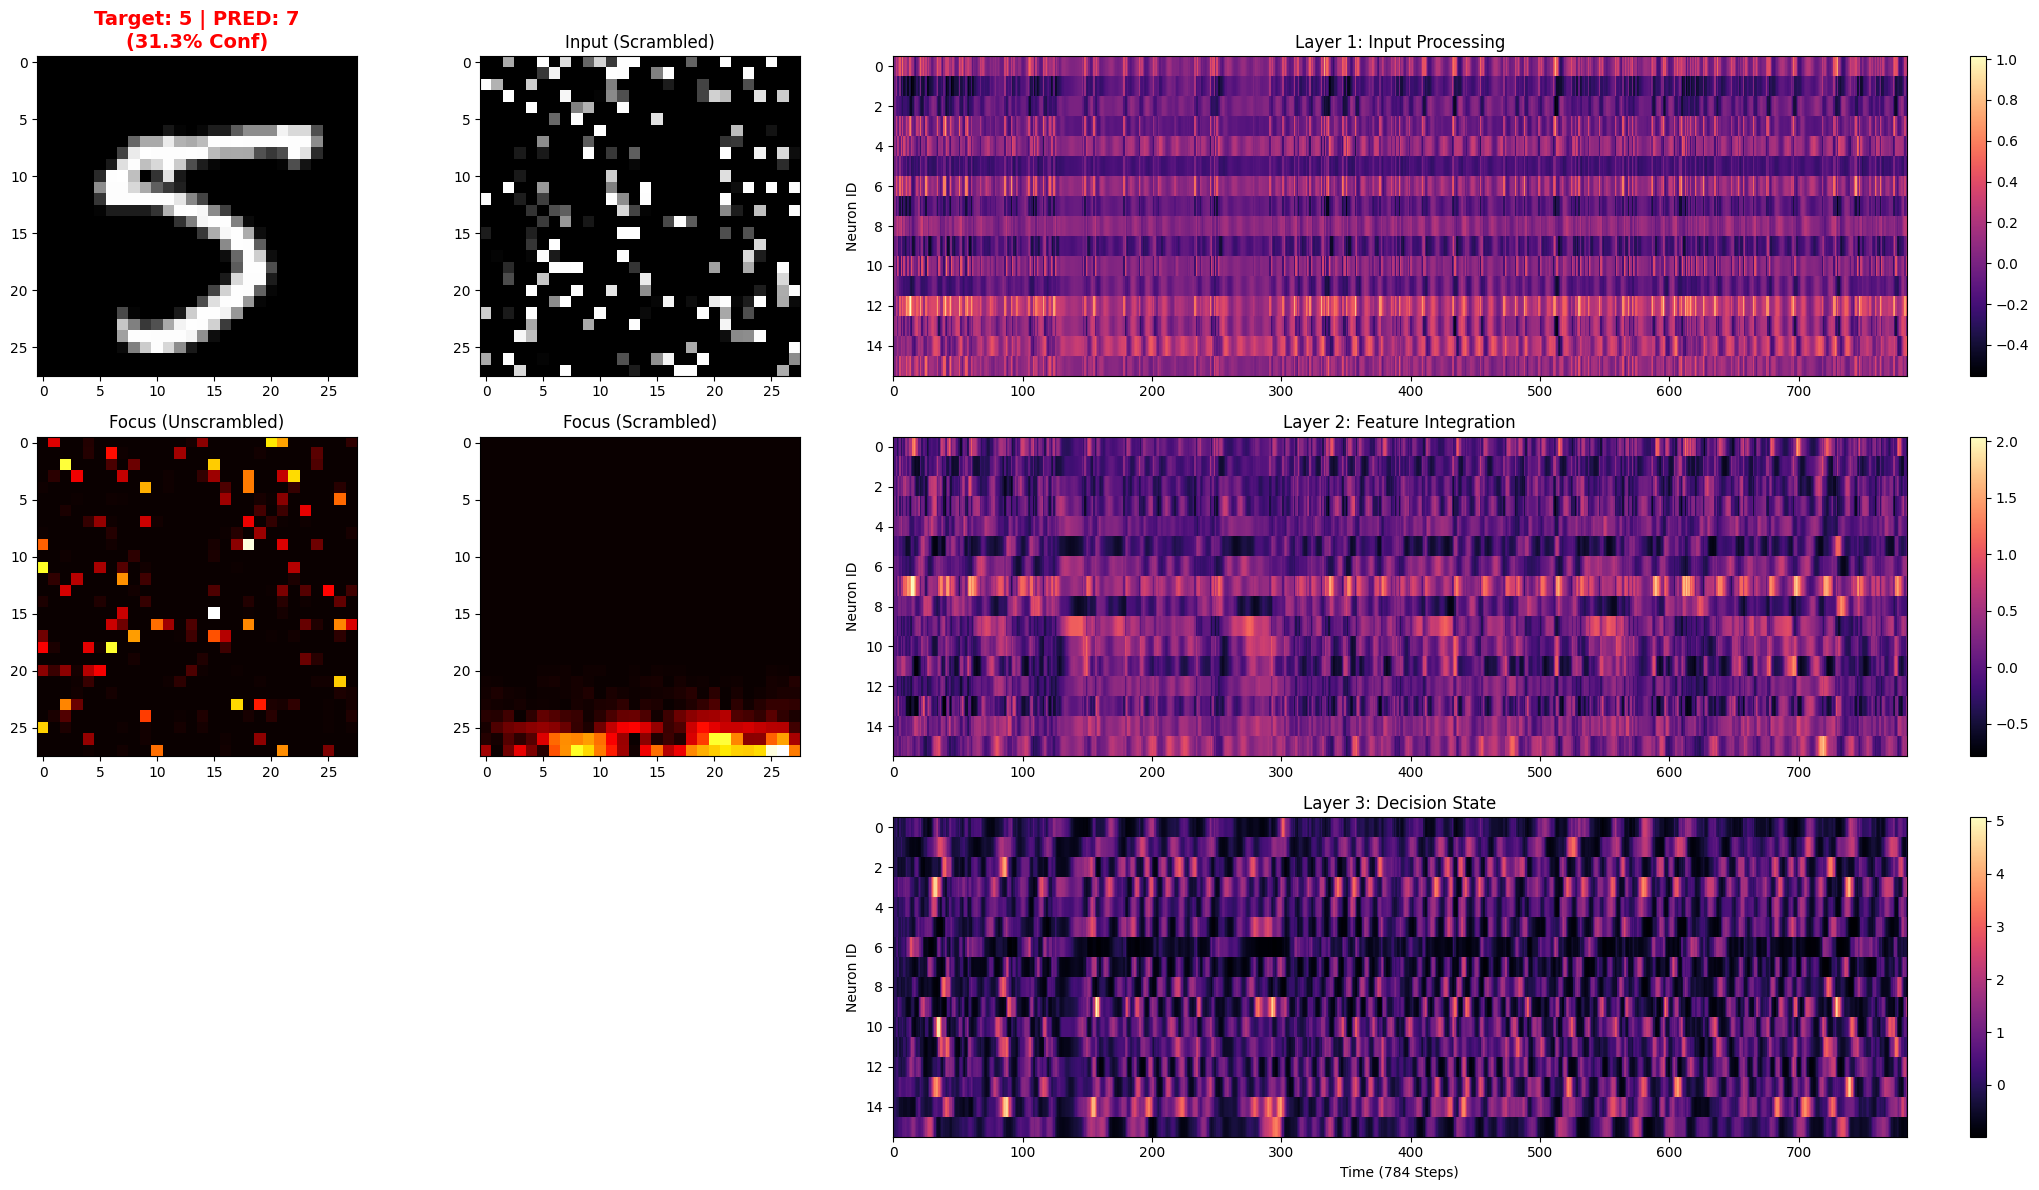

In [7]:
def visualize_pmnist_complete(model, image, label, permutation):
    # 1. Setup Inverse Permutation
    inverse_perm = np.argsort(permutation)
    img_tensor = tf.convert_to_tensor(image[np.newaxis, ...], dtype=tf.float32)
    
    # 2. Manual hidden state extraction
    h1_seq = model.rnn1(img_tensor, training=False)
    h2_seq = model.rnn2(h1_seq, training=False)
    h3_seq = model.rnn3(h2_seq, training=False)
    
    # 3. Get Prediction and Gradients for Saliency
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)        
        output = model(img_tensor, training=False)
        logits = output[0] if isinstance(output, tuple) else output
        
        # Calculate Prediction and Confidence
        probs = tf.nn.softmax(logits, axis=-1)
        pred_label = np.argmax(probs.numpy(), axis=-1)[0]
        confidence = np.max(probs.numpy(), axis=-1)[0]
        
        loss = logits[0, label]

    grads = tape.gradient(loss, img_tensor)
    saliency_flat = tf.reduce_max(tf.abs(grads), axis=-1).numpy().flatten()
    
    # 4. Prepare Images (Clean vs Scrambled)
    unscrambled_img = image.flatten()[inverse_perm].reshape(28, 28)
    unscrambled_sal = saliency_flat[inverse_perm].reshape(28, 28)
    scrambled_img = image.reshape(28, 28)
    scrambled_sal = saliency_flat.reshape(28, 28)

    # --- PLOTTING ---
    fig = plt.figure(figsize=(22, 12))
    
    # Color the title based on correctness
    result_color = "green" if pred_label == label else "red"
    
    # COLUMN 1: UNSCRAMBLED (The "Truth")
    ax1 = plt.subplot2grid((3, 5), (0, 0))
    ax1.imshow(unscrambled_img, cmap='gray')
    ax1.set_title(f"Target: {label} | PRED: {pred_label}\n({confidence*100:.1f}% Conf)", 
                  fontsize=14, color=result_color, fontweight='bold')
    
    ax2 = plt.subplot2grid((3, 5), (1, 0))
    ax2.imshow(unscrambled_sal, cmap='hot')
    ax2.set_title("Focus (Unscrambled)")

    # COLUMN 2: SCRAMBLED (The "Reality")
    ax3 = plt.subplot2grid((3, 5), (0, 1))
    ax3.imshow(scrambled_img, cmap='gray')
    ax3.set_title("Input (Scrambled)")
    
    ax4 = plt.subplot2grid((3, 5), (1, 1))
    ax4.imshow(scrambled_sal, cmap='hot')
    ax4.set_title("Focus (Scrambled)")

    # COLUMN 3-5: THE HIDDEN HEARTBEATS
    layers = [h1_seq, h2_seq, h3_seq]
    layer_names = ["Layer 1: Input Processing", "Layer 2: Feature Integration", "Layer 3: Decision State"]
    
    for i, (h_seq, name) in enumerate(zip(layers, layer_names)):
        ax = plt.subplot2grid((3, 5), (i, 2), colspan=3)
        activity = tf.transpose(h_seq[0]).numpy()
        im = ax.imshow(activity, aspect='auto', cmap='magma', interpolation='nearest')
        ax.set_title(name)
        ax.set_ylabel("Neuron ID")
        if i == 2: ax.set_xlabel("Time (784 Steps)")
        plt.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()

# Run it!
visualize_pmnist_complete(model_active, x_test[102], y_test[102], perm)

In [ ]:
def evaluate_reversed_memory(model, x_test, y_test):
    # 1. Flip the time axis: [Batch, 784, 1] -> [Batch, 784(reversed), 1]
    x_rev = x_test[:, ::-1, :]
    
    # 2. Setup batch processing
    test_ds_rev = tf.data.Dataset.from_tensor_slices((x_rev, y_test)).batch(BATCH_SIZE)
    
    # 3. Running Inference
    correct_count = 0
    total_count = 0
    
    print(f"Checking Memory Persistence on {len(x_test)} Reversed Samples...")
    for x_batch, y_batch in test_ds_rev:
        logits, _ = model(x_batch, training=False)
        preds = tf.argmax(logits, axis=-1, output_type=tf.int32)
        correct_count += tf.reduce_sum(tf.cast(tf.equal(preds, y_batch), tf.int32)).numpy()
        total_count += y_batch.shape[0]
        
    rev_acc = (correct_count / total_count) * 100
    return rev_acc

# Run the check
reversed_accuracy = evaluate_reversed_memory(model_active, x_test, y_test)

print(f"\n{'='*40}")
print(f" REVERSAL MEMORY CHECK")
print(f"{'='*40}")
print(f" Standard pMNIST Acc : {test_acc_active*100:.2f}%")
print(f" Reversed pMNIST Acc : {reversed_accuracy:.2f}%")
print(f" Retention Ratio     : {(reversed_accuracy/(test_acc_active*100)):.2f}x")
print(f"{'='*40}")

Checking Memory Persistence on 10000 Reversed Samples...

 REVERSAL MEMORY CHECK
 Standard pMNIST Acc : 56.64%
 Reversed pMNIST Acc : 10.80%
 Retention Ratio     : 0.19x


Time-Reversed Test Set Ready: (10000, 784, 1)


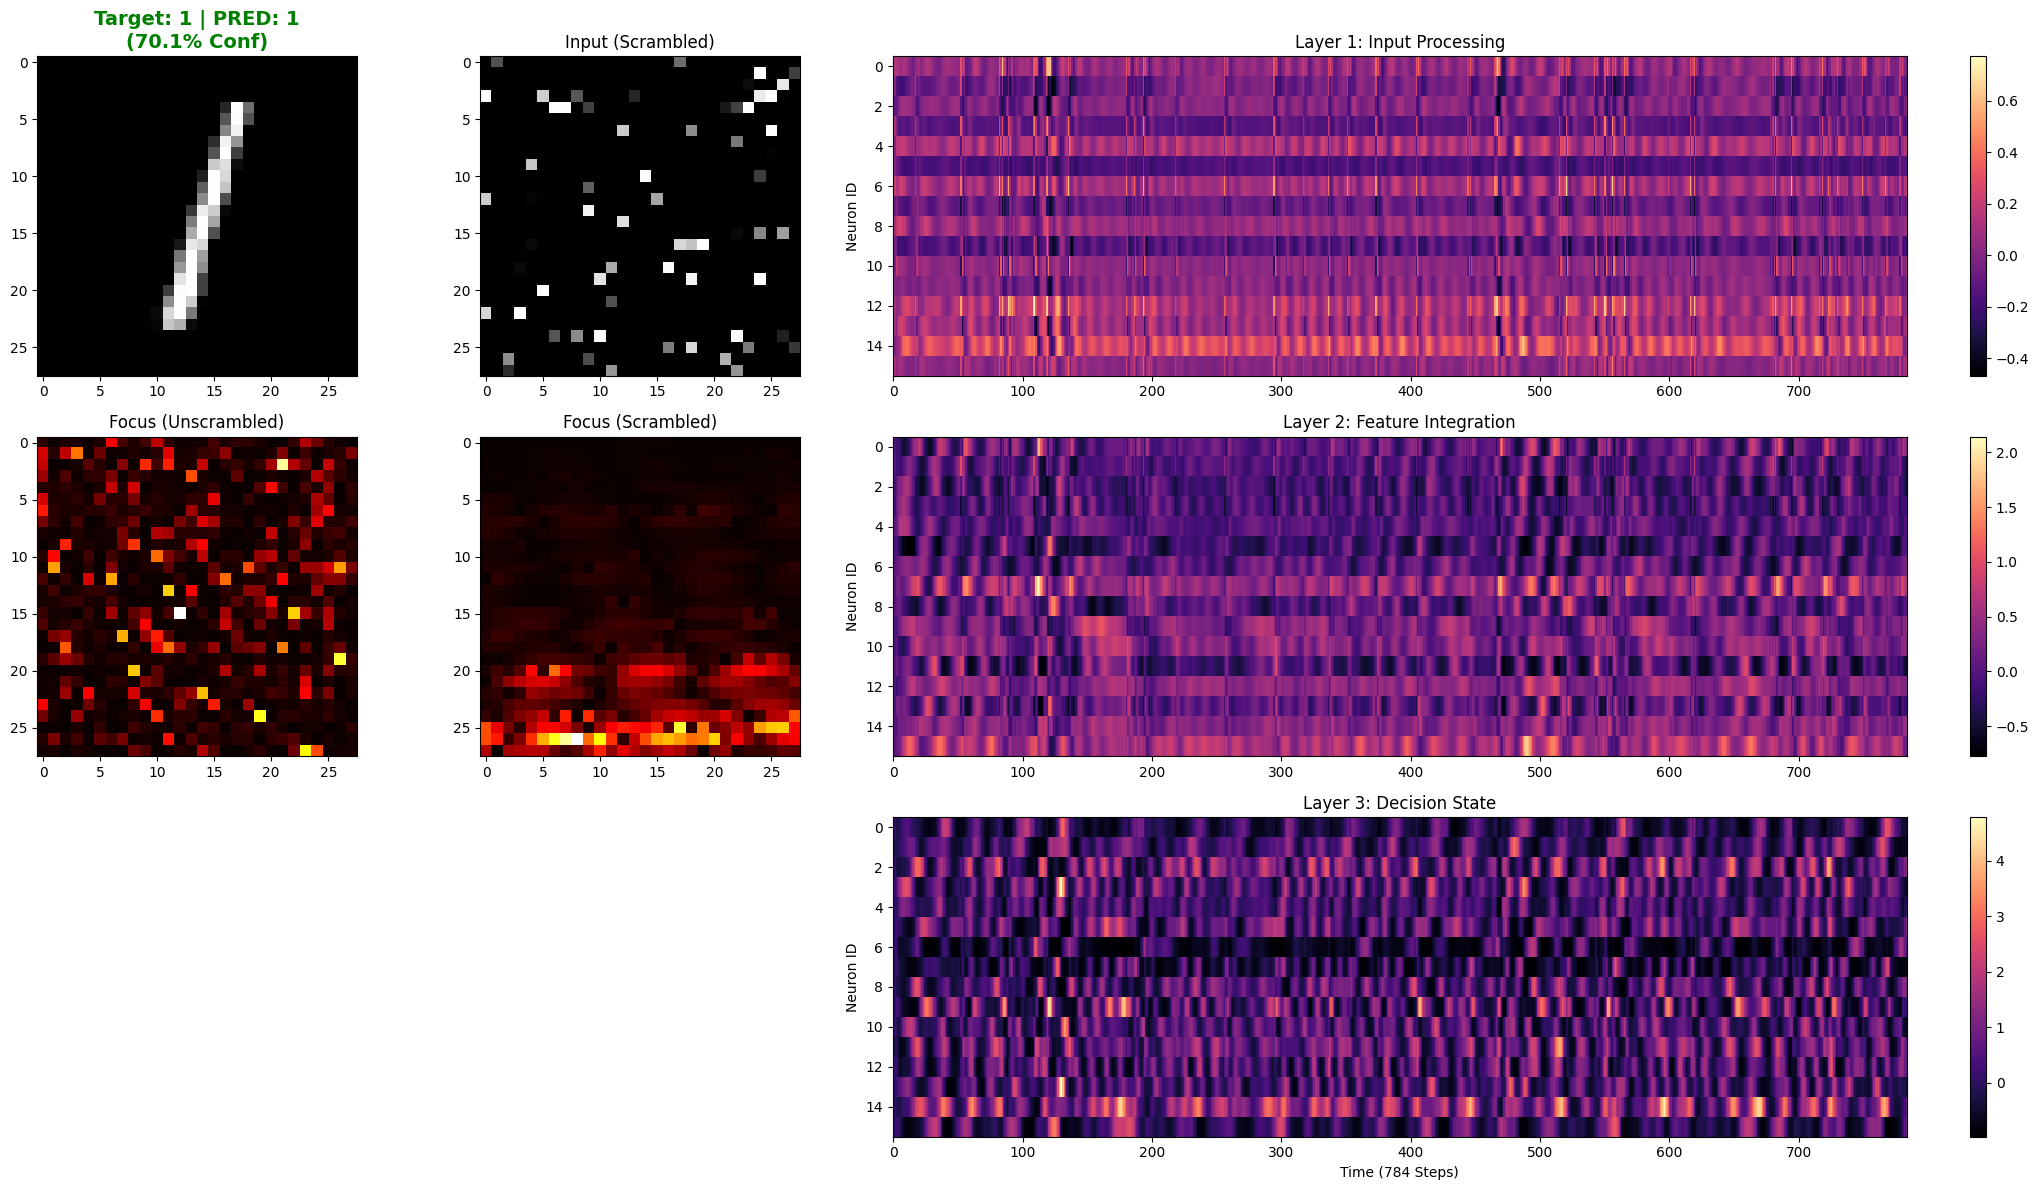

In [ ]:
# --- REVERSAL TEST ---
# We take the existing x_test (already permuted) and flip the time axis
x_test_reversed = x_test[:, ::-1, :] 

print(f"Time-Reversed Test Set Ready: {x_test_reversed.shape}")

# Run the complete visualization on the SAME digit, but reversed
# Note: We pass 'perm[::-1]' to account for the reversal in the unscrambler
visualize_pmnist_complete(model_active, x_test_reversed[99], y_test[99], perm[::-1])